<a href="https://colab.research.google.com/github/shaikmujamil144/Mlops/blob/main/MLLab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pandas scikit-learn matplotlib joblib mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 583.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
from google.colab import files

DATA_PATH = "/content/titanic.csv"

if not os.path.exists(DATA_PATH):
    print("Please upload titanic.csv")
    uploaded = files.upload()

    uploaded_name = next(iter(uploaded))

    if uploaded_name != "titanic.csv":
        os.rename(uploaded_name, DATA_PATH)
else:
    print("Using existing file:", DATA_PATH)

Using existing file: /content/titanic.csv


In [ ]:
df = pd.read_csv(DATA_PATH)

required_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "Survived"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(df.head())

print("\nMissing values:")
print(df[required_columns].isnull().sum())

print("\nTarget distribution:")
print(df["Survived"].value_counts())

Dataset loaded successfully.
Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing values:
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
feature_columns = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[feature_columns].copy()
y = df["Survived"].copy()

print("Features:")
print(feature_columns)

print("\nTarget: Survived")

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

Target: Survived


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 712
Testing records: 179


In [ ]:
numerical_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked"
]

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

baseline_start = time.time()

baseline_pipeline.fit(
    X_train,
    y_train
)

baseline_runtime = time.time() - baseline_start

baseline_predictions = baseline_pipeline.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print(
    "Baseline test accuracy:",
    round(baseline_accuracy, 4)
)

print(
    "Baseline runtime:",
    round(baseline_runtime, 2),
    "seconds"
)

print("\nClassification report:")

print(
    classification_report(
        y_test,
        baseline_predictions
    )
)

Baseline test accuracy: 0.7933
Baseline runtime: 0.23 seconds

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [50, 100, 200],

    "model__max_depth": [
        None,
        5,
        10
    ],

    "model__min_samples_split": [
        2,
        5
    ],

    "model__min_samples_leaf": [
        1,
        2
    ]
}

number_of_grid_combinations = 1

for values in param_grid.values():
    number_of_grid_combinations *= len(values)

print(
    "Grid combinations:",
    number_of_grid_combinations
)

print(
    "Approximate model fits:",
    number_of_grid_combinations * 5
)

Grid combinations: 36
Approximate model fits: 180


In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting Grid Search...")

grid_start = time.time()

grid_search.fit(
    X_train,
    y_train
)

grid_runtime = time.time() - grid_start

print("\nGrid Search completed.")

print("\nBest Parameters:")
print(grid_search.best_params_)

print(
    "\nBest CV Accuracy:",
    round(grid_search.best_score_, 4)
)

print(
    "Grid Search Runtime:",
    round(grid_runtime, 2),
    "seconds"
)

Starting Grid Search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Grid Search completed.

Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 50}

Best CV Accuracy: 0.8273
Grid Search Runtime: 37.0 seconds


In [ ]:
grid_best_model = grid_search.best_estimator_

grid_predictions = grid_best_model.predict(
    X_test
)

grid_accuracy = accuracy_score(
    y_test,
    grid_predictions
)

print("Grid Search Test Accuracy:", round(grid_accuracy, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        grid_predictions
    )
)

Grid Search Test Accuracy: 0.7989

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



In [ ]:
param_distributions = {
    "model__n_estimators": [
        50, 100, 150, 200, 300, 400
    ],

    "model__max_depth": [
        None, 3, 5, 8, 10, 15
    ],

    "model__min_samples_split": [
        2, 4, 6, 8, 10
    ],

    "model__min_samples_leaf": [
        1, 2, 4, 6
    ],

    "model__max_features": [
        "sqrt", "log2", None
    ]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=5,
    scoring="accuracy",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Starting Randomized Search...")

random_start = time.time()

random_search.fit(
    X_train,
    y_train
)

random_runtime = time.time() - random_start

print("\nRandomized Search completed.")

print("\nBest Parameters:")
print(random_search.best_params_)

print(
    "\nBest CV Accuracy:",
    round(random_search.best_score_, 4)
)

print(
    "Randomized Search Runtime:",
    round(random_runtime, 2),
    "seconds"
)

Starting Randomized Search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Randomized Search completed.

Best Parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 8, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 15}

Best CV Accuracy: 0.8288
Randomized Search Runtime: 45.96 seconds


In [ ]:
random_best_model = random_search.best_estimator_

random_predictions = random_best_model.predict(
    X_test
)

random_accuracy = accuracy_score(
    y_test,
    random_predictions
)

print(
    "Random Search Test Accuracy:",
    round(random_accuracy, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        random_predictions
    )
)

Random Search Test Accuracy: 0.8101

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.91      0.85       110
           1       0.82      0.65      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
comparison_df = pd.DataFrame({
    "Method": [
        "Baseline",
        "Grid Search",
        "Random Search"
    ],

    "CV Accuracy": [
        None,
        grid_search.best_score_,
        random_search.best_score_
    ],

    "Test Accuracy": [
        baseline_accuracy,
        grid_accuracy,
        random_accuracy
    ],

    "Runtime (seconds)": [
        baseline_runtime,
        grid_runtime,
        random_runtime
    ]
})

comparison_df["Test Accuracy (%)"] = (
    comparison_df["Test Accuracy"] * 100
)

comparison_df["Improvement vs Baseline (pp)"] = (
    comparison_df["Test Accuracy"]
    - baseline_accuracy
) * 100

display(comparison_df.round(4))

,Method,CV Accuracy,Test Accuracy,Runtime (seconds),Test Accuracy (%),Improvement vs Baseline (pp)
0,Baseline,NaN,0.7933,0.2256,79.3296,0.0000
1,Grid Search,0.8273,0.7989,37.0048,79.8883,0.5587
2,Random Search,0.8288,0.8101,45.9592,81.0056,1.6760


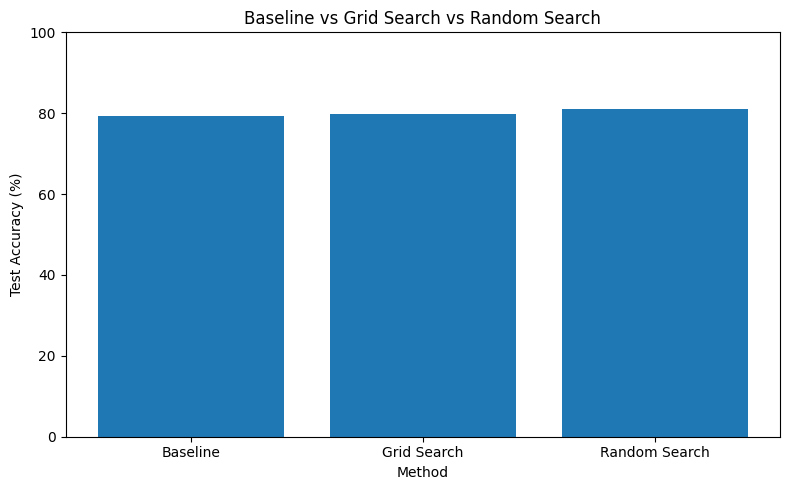

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Test Accuracy (%)"]
)

plt.xlabel("Method")
plt.ylabel("Test Accuracy (%)")
plt.title("Baseline vs Grid Search vs Random Search")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
grid_results = pd.DataFrame(
    grid_search.cv_results_
)

top_grid = grid_results[
    [
        "param_model__n_estimators",
        "param_model__max_depth",
        "param_model__min_samples_split",
        "param_model__min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values(
    "rank_test_score"
).head(10)

display(top_grid)

,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
33,50,10,5,2,0.827342,0.031656,1
8,200,None,2,2,0.827332,0.028805,2
35,200,10,5,2,0.827332,0.027013,2
32,200,10,2,2,0.827322,0.024410,4
7,100,None,2,2,0.827322,0.027828,5
34,100,10,5,2,0.825933,0.028657,6
10,100,None,5,2,0.825914,0.029131,7
29,200,10,5,1,0.825904,0.025950,8
11,200,None,5,2,0.824525,0.029905,9
28,100,10,5,1,0.824505,0.027259,10


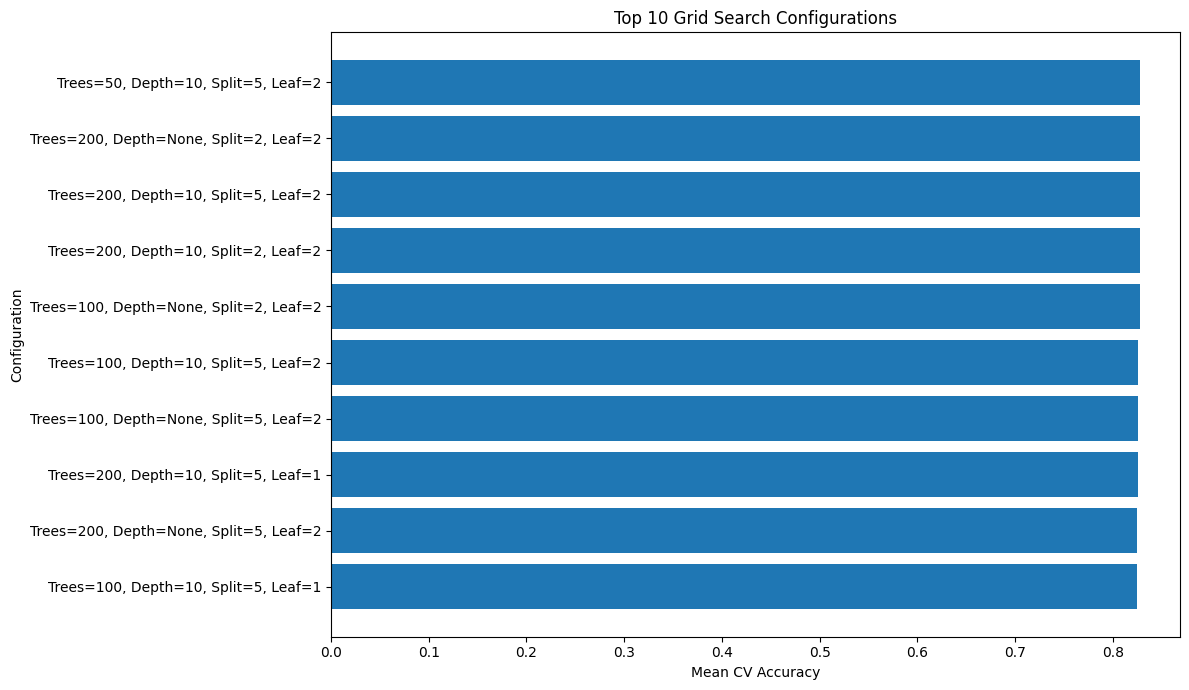

In [ ]:
top_grid = top_grid.copy()

top_grid["Configuration"] = (
    "Trees="
    + top_grid["param_model__n_estimators"].astype(str)
    + ", Depth="
    + top_grid["param_model__max_depth"].astype(str)
    + ", Split="
    + top_grid["param_model__min_samples_split"].astype(str)
    + ", Leaf="
    + top_grid["param_model__min_samples_leaf"].astype(str)
)

top_grid = top_grid.iloc[::-1]

plt.figure(figsize=(12, 7))

plt.barh(
    top_grid["Configuration"],
    top_grid["mean_test_score"]
)

plt.xlabel("Mean CV Accuracy")
plt.ylabel("Configuration")
plt.title("Top 10 Grid Search Configurations")

plt.tight_layout()
plt.show()

In [ ]:
grid_improvement = (
    grid_accuracy - baseline_accuracy
) * 100

random_improvement = (
    random_accuracy - baseline_accuracy
) * 100

print(
    "Baseline Accuracy:",
    round(baseline_accuracy * 100, 2),
    "%"
)

print(
    "Grid Search Accuracy:",
    round(grid_accuracy * 100, 2),
    "%"
)

print(
    "Random Search Accuracy:",
    round(random_accuracy * 100, 2),
    "%"
)

print()

print(
    "Grid Search Improvement:",
    f"{grid_improvement:+.2f}",
    "percentage points"
)

print(
    "Random Search Improvement:",
    f"{random_improvement:+.2f}",
    "percentage points"
)

Baseline Accuracy: 79.33 %
Grid Search Accuracy: 79.89 %
Random Search Accuracy: 81.01 %

Grid Search Improvement: +0.56 percentage points
Random Search Improvement: +1.68 percentage points


In [ ]:
model_candidates = {
    "Baseline": (
        baseline_accuracy,
        baseline_pipeline
    ),

    "Grid Search": (
        grid_accuracy,
        grid_best_model
    ),

    "Random Search": (
        random_accuracy,
        random_best_model
    )
}

best_method = max(
    model_candidates,
    key=lambda x: model_candidates[x][0]
)

final_accuracy, final_model = model_candidates[
    best_method
]

FINAL_MODEL_PATH = "/content/best_titanic_random_forest.pkl"

joblib.dump(
    final_model,
    FINAL_MODEL_PATH
)

print("Selected Model:", best_method)

print(
    "Final Test Accuracy:",
    round(final_accuracy * 100, 2),
    "%"
)

print(
    "Saved to:",
    FINAL_MODEL_PATH
)

Selected Model: Random Search
Final Test Accuracy: 81.01 %
Saved to: /content/best_titanic_random_forest.pkl


In [ ]:
loaded_model = joblib.load(
    FINAL_MODEL_PATH
)

print("Model reloaded successfully.")

Model reloaded successfully.


In [ ]:
new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [29],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [85.0],
    "Embarked": ["C"]
})

prediction = loaded_model.predict(
    new_passenger
)[0]

print("Prediction:", prediction)

if prediction == 1:
    print("Result: Survived")
else:
    print("Result: Did Not Survive")

Prediction: 1
Result: Survived


In [ ]:
print("=" * 50)
print("HYPERPARAMETER TUNING SUMMARY")
print("=" * 50)

print(
    f"Baseline Test Accuracy : {baseline_accuracy:.4f}"
)

print(
    f"Grid Search Test       : {grid_accuracy:.4f}"
)

print(
    f"Random Search Test     : {random_accuracy:.4f}"
)

print()

print(
    "Grid Best Parameters:"
)

print(
    grid_search.best_params_
)

print()

print(
    "Random Best Parameters:"
)

print(
    random_search.best_params_
)

print()

print(
    f"Selected Model         : {best_method}"
)

print(
    f"Final Test Accuracy    : {final_accuracy:.4f}"
)

print()

print("Model saved and reloaded successfully.")
print("Experiment completed successfully.")

HYPERPARAMETER TUNING SUMMARY
Baseline Test Accuracy : 0.7933
Grid Search Test       : 0.7989
Random Search Test     : 0.8101

Grid Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 50}

Random Best Parameters:
{'model__n_estimators': 150, 'model__min_samples_split': 8, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 15}

Selected Model         : Random Search
Final Test Accuracy    : 0.8101

Model saved and reloaded successfully.
Experiment completed successfully.


In [ ]:
import os

print("Model exists:", os.path.exists(FINAL_MODEL_PATH))
print("Model path:", FINAL_MODEL_PATH)

Model exists: True
Model path: /content/best_titanic_random_forest.pkl


In [ ]:
loaded_model = joblib.load(FINAL_MODEL_PATH)

print("Model reloaded successfully.")

Model reloaded successfully.


In [ ]:
new_passenger = pd.DataFrame({
    "Pclass": [1],
    "Sex": ["female"],
    "Age": [29],
    "SibSp": [0],
    "Parch": [0],
    "Fare": [85.0],
    "Embarked": ["C"]
})

prediction = loaded_model.predict(new_passenger)[0]

print("Prediction:", prediction)

if prediction == 1:
    print("Result: Survived")
else:
    print("Result: Did Not Survive")

Prediction: 1
Result: Survived
